In [1]:
from quafu import User
user = User("oL6riRwK5Y2x9iLrHw2t7ehH6W4rNJqxzr5xDgSZ25g.QfzkTO2MzM2QzNxojIwhXZiwyM1gDN6ICZpJye.9JiN1IzUIJiOicGbhJCLiQ1VKJiOiAXe0Jye")
user.save_apitoken()

In [2]:
available_backends = user.get_available_backends()

system_name	 qubits	 status
ScQ-P10   	 10   	 Offline
ScQ-P18   	 18   	 Obsolete
Baiwang   	 136  	 Obsolete
ScQ-P102  	 102  	 Obsolete
ScQ-Sim10 	 10   	 Online
Miaofeng  	 108  	 Obsolete
Dongling  	 105  	 Offline
Haituo    	 105  	 Offline
Baihua    	 119  	 Online
Yunmeng   	 156  	 Obsolete
Xiang     	 35   	 Obsolete
ScQ-TEST  	 3    	 Offline
ScQ-P21   	 11   	 Offline
ScQ-Sim   	 2    	 Obsolete


In [3]:
import numpy as np
from quafu import QuantumCircuit

qc = QuantumCircuit(5)

In [4]:
qc.x(0)
qc.x(1)
qc.cnot(2, 1)
qc.ry(1, np.pi/2)
qc.rx(2, np.pi)
qc.rz(3, 0.1)
qc.cz(2, 3)

In [5]:
measures = [0, 1, 2, 3, 4]
cbits = [0, 1, 2, 4, 3]
qc.measure(measures,  cbits=cbits)
qc.measures

{0: 0, 1: 1, 2: 2, 3: 4, 4: 3}

In [6]:
qc.draw_circuit(width=4)

q[0]  ------X----------------------------- M->c[0]
                                          
q[1]  ------X--------+----RY(1.571)------- M->c[1]
                     |                    
q[2]  ---------------*----RX(3.142)----*-- M->c[2]
                                       |  
q[3]  --RZ(0.100)----------------------Z-- M->c[4]
                                          
q[4]  ------------------------------------ M->c[3]


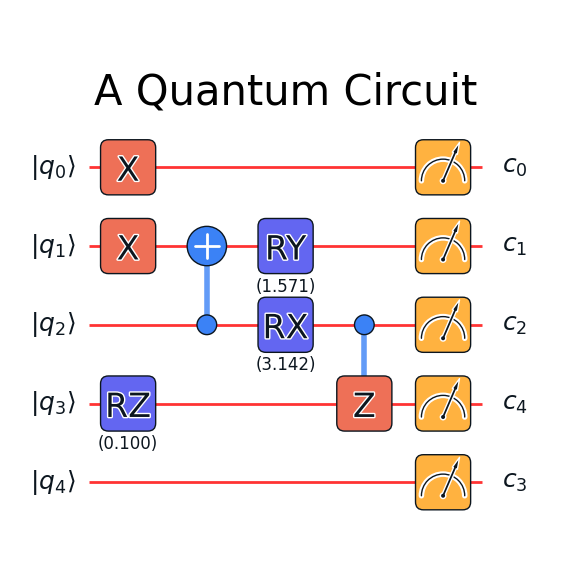

In [7]:
qc.plot_circuit(title='A Quantum Circuit')

In [8]:
qasm = qc.to_openqasm()
print(qasm)

OPENQASM 2.0;
include "qelib1.inc";
qreg q[5];
creg meas[5];
x q[0];
x q[1];
cx q[2],q[1];
ry(1.5707963267948966) q[1];
rx(3.141592653589793) q[2];
rz(0.1) q[3];
cz q[2],q[3];
measure q[0] -> meas[0];
measure q[1] -> meas[1];
measure q[2] -> meas[2];
measure q[3] -> meas[4];
measure q[4] -> meas[3];



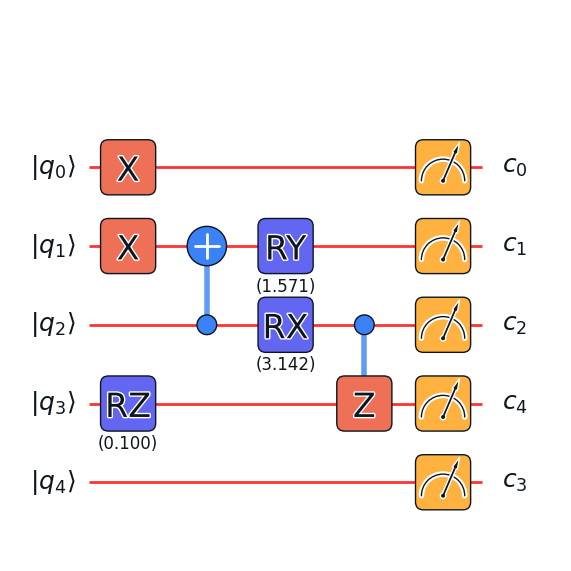

In [9]:
del qc
qc = QuantumCircuit(5)
qc.from_openqasm(qasm)
qc.plot_circuit('Recovered from QASM')

In [10]:
from quafu import Task
task = Task()

In [11]:
task.config(backend="Baihua", shots=2000, compile=True)

In [12]:
my_task = task.send(qc)

In [13]:
my_task.task_status

'In Queue'

In [14]:
my_task.taskid

'61F34D200917AAD3'

In [ ]:
# dir(my_task)
# 

In [15]:
# After task is done, you could fetch results as below
res = task.retrieve(my_task.taskid)

OrderedDict()
{}


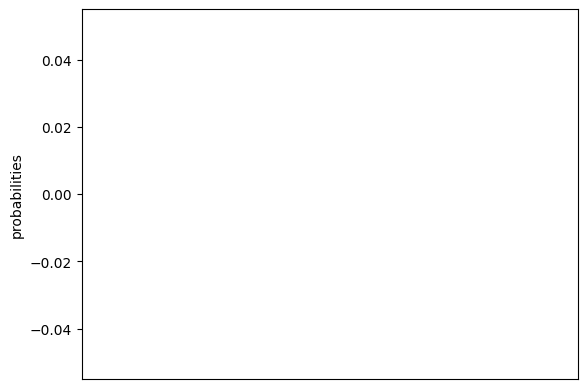

In [16]:
print(res.counts) #counts
print(res.probabilities) #probabilities
res.plot_probabilities()

In [17]:
res = task.retrieve("5DB998D0270C98EA")

In [18]:
type(my_task)

quafu.results.results.ExecResult

In [19]:
type(res)

quafu.results.results.ExecResult

OrderedDict([('00', 1451), ('01', 59), ('10', 83), ('11', 1407)])
{'00': 0.4836666666666667, '01': 0.019666666666666666, '10': 0.027666666666666666, '11': 0.469}


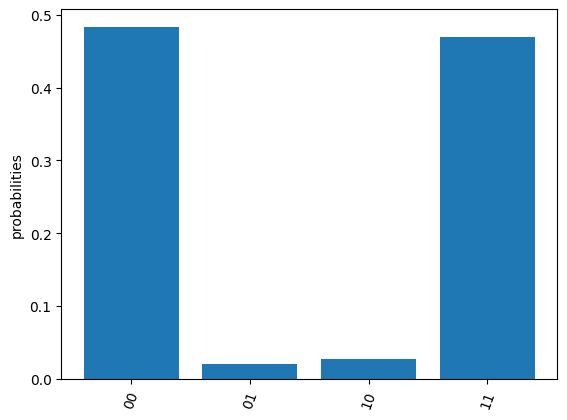

In [20]:
print(res.counts) #counts
print(res.probabilities) #probabilities
res.plot_probabilities()